# Roster-Solver Visualisations

This notebook explores `roster-solver` — a CP-SAT based scheduler that assigns a
pool of workers to bike-riding / road-safety training events. It must satisfy
three **hard constraints** (each event staffed exactly, per-skill minimums
2 mech / 2 first-aid / 1 leader, no worker double-booked in one time slot)
while **minimising a weighted inconvenience objective** `z` made of five soft
terms: `same_group`, `priority`, `same_location`, `proportional_split` and
`neighbourhood`.

Every scenario below is **synthetic**: real roster data is not shipped with the
repo, so `roster_solver.synthetic.make_problem` builds anonymised, seeded
problems. The plotting code lives in `roster_solver.plots` as **pure
functions** — they take plain dictionaries and return a `matplotlib` figure;
this notebook generates the data, runs the solver, and hands the results over.

## Contents

1. **Roster grid** — worker × time-slot heatmap of a solved schedule: team
   consistency across a class' sessions (same colour), no double-booking.
2. **Scaling** — wall time and model size vs total staffing demand, and where
   CP-SAT stops proving optimality within a time budget.
3. **Gap decay** — one long solve with all objective terms balanced: the
   incumbent objective drops in steps while the proven bound creeps up; the
   shaded area is the remaining optimality gap.
4. **Fairness** — workload distribution with and without the
   `proportional_split` term, which pushes each priority level towards an
   availability-weighted share.

Figures are saved to `figures/*.png`.

## Setup & imports

In [1]:
import sys
from pathlib import Path

# Make `roster_solver` importable whether this notebook is opened from the repo
# root or from its own directory (the package is not installed, only on PYTHONPATH).
for candidate in (Path("src"), Path("../src")):
    if candidate.is_dir():
        sys.path.insert(0, str(candidate.resolve()))
        break

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

from ortools.sat.python import cp_model

from roster_solver import plots
from roster_solver.solver import CpSatScheduler
from roster_solver.structures import DEFAULT_COEFFICIENTS
from roster_solver.synthetic import make_problem

## 1. Roster grid

Generate one instance and solve it with the default (near-lexicographic)
weights. Each cell is a worker-slot assignment: fill colour = `group_id`
(class), label = location. Rows are workers, columns are time slots — a worker
is never coloured twice in the same column (no double-booking), and a class'
sessions share the same colour team (team consistency).

status=OPTIMAL  z=248419
objective breakdown: {'same_group': 0, 'priority': 12, 'same_location': 126, 'proportional_split': 2334, 'neighbourhood': 85}


saved /mnt/local_storage/code/cycliste_averti_schedule/figures/roster_grid.png


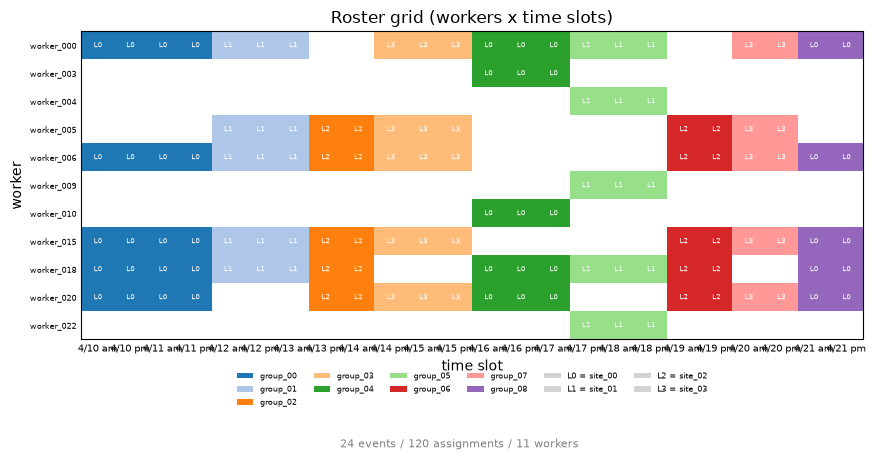

In [2]:
events, workers = make_problem(n_workers=24, n_events=24, seed=1)
scheduler = CpSatScheduler(events, workers)
sol = scheduler.solve(max_seconds=30.0)
assert sol is not None, scheduler.status_name()

print(f"status={scheduler.status_name()}  z={scheduler.objective_value():.0f}")
print("objective breakdown:", scheduler.objective_breakdown())

schedule = sol.to_dict(events)
fig = plots.plot_roster_grid(schedule)
plots.save_figure(fig, "roster_grid", "../figures")
plt.show()

## 2. Scaling

Grow the problem (total staffing demand = `n_events × workers_per_event`) and
record wall time and model size for a fixed 5 s time budget. Two regimes should
stand out: small problems solve to **OPTIMAL** almost instantly, then the model
keeps growing (assignments + team-consistency variables) and the solver can no
longer *prove* optimality within the budget — it stops with a **FEASIBLE**
schedule instead.

demand=  20 OPTIMAL   time= 0.02s vars=   174


demand=  30 OPTIMAL   time= 0.27s vars=   407


demand=  40 OPTIMAL   time= 0.51s vars=   927


demand=  50 FEASIBLE  time= 5.01s vars=  1602


demand=  60 FEASIBLE  time= 5.01s vars=  1981


...

demand= 160 FEASIBLE  time= 5.06s vars= 24990


demand= 170 FEASIBLE  time= 5.07s vars= 30809


demand= 180 UNKNOWN   time= 5.10s vars= 37139


demand= 190 UNKNOWN   time= 4.99s vars= 40375


saved /mnt/local_storage/code/cycliste_averti_schedule/figures/scaling.png


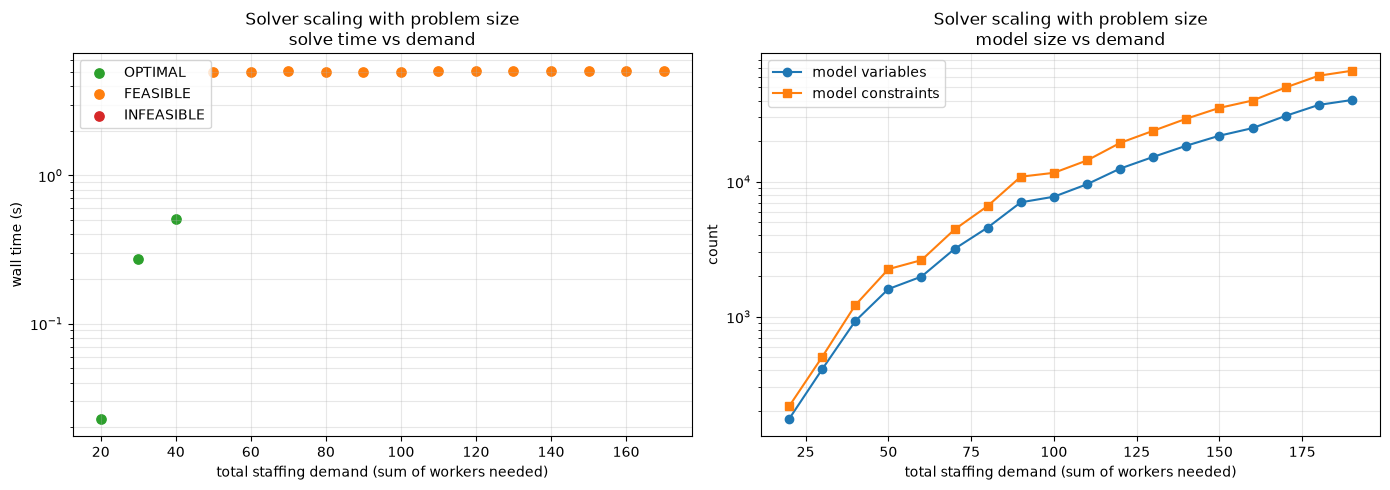

In [3]:
results = []
for i in range(18):
    n_events = 4 + 2 * i
    demand = n_events * 5
    n_workers = int(demand * 1.3)
    events, workers = make_problem(
        n_workers=n_workers, n_events=n_events, workers_per_event=5, seed=100 + i
    )
    scheduler = CpSatScheduler(events, workers)
    scheduler.solve(max_seconds=5.0)
    results.append({
        "demand": demand,
        "n_events": n_events,
        "n_workers": n_workers,
        "wall_time": scheduler.solver.WallTime(),
        "status": scheduler.status_name(),
        "n_vars": len(scheduler.model.proto.variables),
        "n_constraints": len(scheduler.model.proto.constraints),
    })
    print(f"demand={demand:4d} {results[-1]['status']:9s} "
          f"time={results[-1]['wall_time']:5.2f}s "
          f"vars={results[-1]['n_vars']:6d}")

fig = plots.plot_scaling(results)
plots.save_figure(fig, "scaling", "../figures")
plt.show()

## 3. Gap decay

CP-SAT finds a *good* feasible schedule very quickly and spends the rest of the
time tightening it while the proven lower bound rises. With the default
lexicographic weights this instance would be solved in ~0.2 s, so here we use
**balanced weights** (every objective term counts equally) — a much richer
trade-off space that shows the classic staircase of incumbents converging onto
the bound. The shaded region between incumbent and bound is the remaining
optimality gap.

status=FEASIBLE  z=4670  bound=1432  incumbents=212
saved /mnt/local_storage/code/cycliste_averti_schedule/figures/gap_decay.png


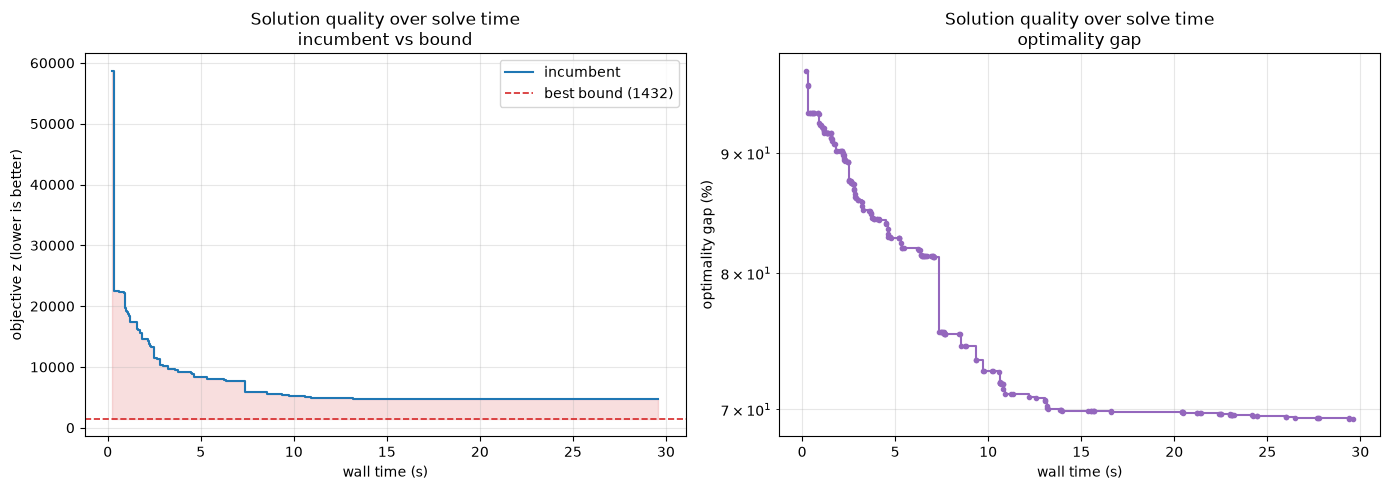

In [4]:
BALANCED_COEFFICIENTS = {
    "same_group": 1, "priority": 1, "same_location": 1,
    "proportional_split": 1, "neighbourhood": 1,
}

events, workers = make_problem(
    n_workers=45, n_events=48, workers_per_event=5,
    availability_density=0.6, reachability_density=0.8,
    skill_density=0.65, seed=21, ensure_feasible=False,
)

# Build the model exactly as CpSatScheduler.solve() does, but with a solution
# callback so we can record every incumbent the solver visits.
scheduler = CpSatScheduler(events, workers)
scheduler.model = cp_model.CpModel()
scheduler._build_variables()
scheduler._add_constraint_team_size()
scheduler._add_constraint_skill_minimums()
scheduler._add_constraint_no_double_booking()
scheduler._add_objective(BALANCED_COEFFICIENTS)

class SolutionLogger(cp_model.CpSolverSolutionCallback):
    def __init__(self):
        super().__init__()
        self.history = []

    def on_solution_callback(self):
        self.history.append((self.wall_time, self.objective_value))

scheduler.solver = cp_model.CpSolver()
scheduler.solver.parameters.max_time_in_seconds = 30.0
logger = SolutionLogger()
scheduler.status = scheduler.solver.solve(scheduler.model, solution_callback=logger)

print(f"status={scheduler.status_name()}  z={scheduler.objective_value():.0f}  "
      f"bound={scheduler.solver.best_objective_bound:.0f}  "
      f"incumbents={len(logger.history)}")

fig = plots.plot_gap_decay({
    "incumbents": logger.history,
    "best_bound": scheduler.solver.best_objective_bound,
})
plots.save_figure(fig, "gap_decay", "../figures")
plt.show()

## 4. Fairness (proportional split on / off)

The `proportional_split` term penalises deviation from an availability-weighted
workload share *within each priority level*. We solve the **same** instance
twice — once without the term, once with it (all other weights balanced) — and
compare the shift counts. With the term, the spread of shifts-per-worker
narrows and workers sit closer to the dashed availability-weighted ideal line.

off: z=144  spread(shifts)=13
 on: z=307  spread(shifts)=6


saved /mnt/local_storage/code/cycliste_averti_schedule/figures/fairness.png


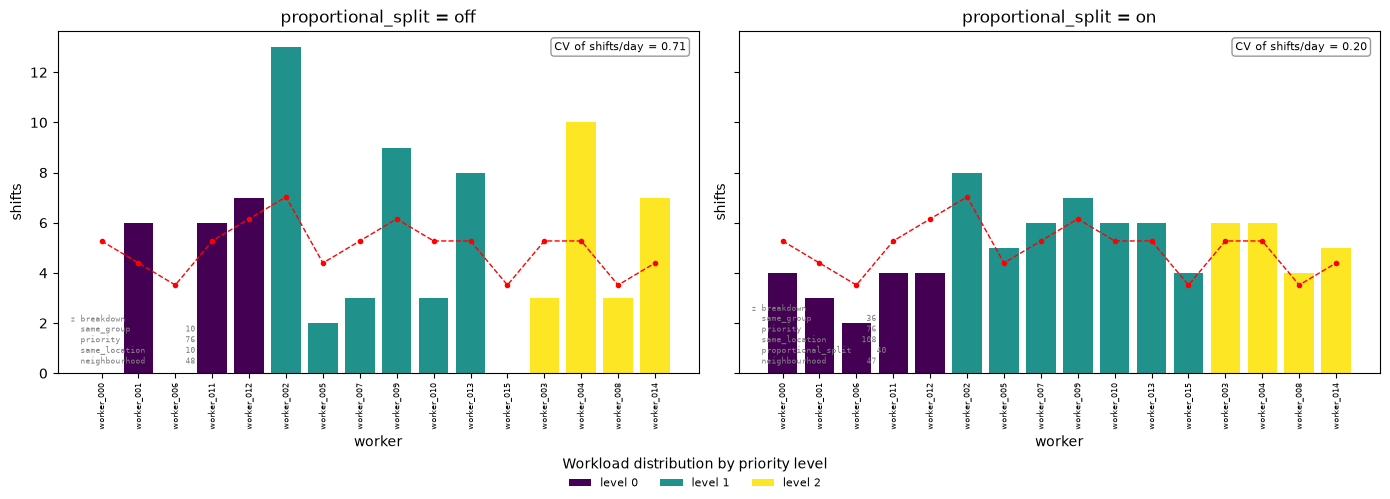

In [5]:
BALANCED = {
    "same_group": 1, "priority": 1, "same_location": 1,
    "proportional_split": 1, "neighbourhood": 1,
}
fairness_cfg = dict(
    n_workers=16, n_events=16, workers_per_event=5,
    availability_density=0.7, reachability_density=0.9,
    skill_density=0.7, seed=5,
)


def solve_fairness(coeffs):
    events, workers = make_problem(**fairness_cfg, ensure_feasible=False)
    scheduler = CpSatScheduler(events, workers)
    sol = scheduler.solve(coefficients=coeffs, max_seconds=15.0)
    assert sol is not None, scheduler.status_name()
    return {
        "shifts": {w.id: len(sol.get_events_for_worker(w)) for w in workers},
        "avail": {w.id: w.get_n_available_dates() for w in workers},
        "level": {w.id: w.priority_level for w in workers},
        "breakdown": scheduler.objective_breakdown(),
        "z": scheduler.objective_value(),
    }


fairness_data = {
    "off": solve_fairness({k: v for k, v in BALANCED.items() if k != "proportional_split"}),
    "on": solve_fairness(BALANCED),
}
for mode, d in fairness_data.items():
    spread = max(d["shifts"].values()) - min(d["shifts"].values())
    print(f"{mode:>3}: z={d['z']:.0f}  spread(shifts)={spread}")

fig = plots.plot_fairness(fairness_data)
plots.save_figure(fig, "fairness", "../figures")
plt.show()

---

All four figures were written to `figures/`. To regenerate them headlessly:

```
PYTHONPATH=src uv run python -m nbconvert --to notebook --execute notebooks/visualisations.ipynb --inplace
```